# Chapter 8: Transforming and Combining Data

*Data Analytics with Python and Jupyter Notebook*

Run each cell in order with **Shift + Enter**. We summarize the Bean There sales with groupby and pivot tables, reshape tables, and merge sales with store, product and target tables.

## 8.1 From rows to answers

We go back to the tidy sales file from Chapter 1 (the cleaned file from Chapter 7 would work too, but the tidy one has every row, so the numbers match Chapter 1).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 80)

sales = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])
sales.head(3)

,date,store,product,category,quantity,unit_price,revenue
0,2026-01-01,Downtown,Espresso,Coffee,30,3.00,90.00
1,2026-01-01,Downtown,Latte,Coffee,53,4.50,238.50
2,2026-01-01,Downtown,Cappuccino,Coffee,35,4.25,148.75


## 8.2 groupby: split, apply, combine

1. **Split** the rows into groups that share a value in the key column (all Downtown rows, all University rows, all Riverside rows).
2. **Apply** a calculation to each group separately (for example, sum the revenue).
3. **Combine** the results into a new, smaller table with one row per group.

In [2]:
sales.groupby("store")["revenue"].sum()

store
Downtown      70205.3
Riverside     40138.2
University    50570.4
Name: revenue, dtype: float64

### Common aggregation functions

For example, the average number of units a store sells of one product on one day:

In [3]:
sales.groupby("store")["quantity"].mean().round(1)

store
Downtown      33.4
Riverside     19.1
University    24.0
Name: quantity, dtype: float64

### Grouping by more than one column

Pass a list of columns to group by every combination of them:

In [4]:
by_store_cat = sales.groupby(["store", "category"])["revenue"].sum()
by_store_cat

store       category
Downtown    Bakery      15485.05
            Coffee      54720.25
Riverside   Bakery       9218.45
            Coffee      30919.75
University  Bakery      11281.15
            Coffee      39289.25
Name: revenue, dtype: float64

`.reset_index()` moves the group labels back into ordinary columns:

In [5]:
by_store_cat.reset_index()

,store,category,revenue
0,Downtown,Bakery,15485.05
1,Downtown,Coffee,54720.25
2,Riverside,Bakery,9218.45
3,Riverside,Coffee,30919.75
4,University,Bakery,11281.15
5,University,Coffee,39289.25


`.unstack()` moves the inner level of the index into the columns, giving a small grid:

In [6]:
by_store_cat.unstack()

category,Bakery,Coffee
store,,
Downtown,15485.05,54720.25
Riverside,9218.45,30919.75
University,11281.15,39289.25


## 8.3 Aggregating several things at once

### Several functions on one column

Pass a list of function names:

In [7]:
sales.groupby("store")["revenue"].agg(["sum", "mean", "max"]).round(2)

,sum,mean,max
store,,,
Downtown,70205.3,130.01,355.5
Riverside,40138.2,74.33,216.0
University,50570.4,93.65,243.0


### Named aggregation

The most readable form is **named aggregation**: you name each output column and say which input column and function produce it, as `new_name=(column, function)`:

In [8]:
store_summary = sales.groupby("store").agg(
    revenue=("revenue", "sum"),
    units=("quantity", "sum"),
    days=("date", "nunique"),
    products=("product", "nunique"),
)
store_summary.round(2)

,revenue,units,days,products
store,,,,
Downtown,70205.3,18013,90,6
Riverside,40138.2,10335,90,6
University,50570.4,12979,90,6


Every store traded on all 90 days and sold all 6 products, which is a useful check in itself. We can add a column computed from the summary itself:

In [9]:
store_summary["revenue_per_day"] = (
    store_summary["revenue"] / store_summary["days"]
).round(2)
store_summary.sort_values("revenue_per_day", ascending=False).round(2)

,revenue,units,days,products,revenue_per_day
store,,,,,
Downtown,70205.3,18013,90,6,780.06
University,50570.4,12979,90,6,561.89
Riverside,40138.2,10335,90,6,445.98


### Your own functions

`agg` also accepts a function you write yourself. It receives each group's values as a Series and must return one number. Here we measure the **range** (largest minus smallest) of daily quantities per product:

In [10]:
def spread(values):
    """Difference between the largest and smallest value."""
    return values.max() - values.min()


sales.groupby("product")["quantity"].agg(["min", "max", spread])

,min,max,spread
product,,,
Blueberry Muffin,5,41,36
Cappuccino,10,58,48
Cold Brew,4,50,46
Croissant,10,53,43
Espresso,7,48,41
Latte,15,79,64


### transform: group results on every row

Sometimes you want a group calculation but **not** a smaller table. Suppose you want each row's share of its store's total revenue. You need the store total repeated on every row of that store. That is what `.transform()` does: it computes per group, then broadcasts the result back to the original rows, so the output has the same length as the input.

In [11]:
store_total = sales.groupby("store")["revenue"].transform("sum")
print(len(sales), len(store_total))
store_total.head(3)

1620 1620


0    70205.3
1    70205.3
2    70205.3
Name: revenue, dtype: float64

1,620 values, one per row. Now dividing two columns of the same length is easy:

In [12]:
sales["share_of_store"] = sales["revenue"] / store_total
(
    sales.groupby(["store", "product"])["share_of_store"]
    .sum()
    .unstack("store")
    .mul(100)
    .round(1)
)

store,Downtown,Riverside,University
product,,,
Blueberry Muffin,9.0,9.1,9.0
Cappuccino,19.2,19.1,19.5
Cold Brew,17.8,17.7,18.1
Croissant,13.0,13.8,13.3
Espresso,11.0,11.1,10.9
Latte,30.0,29.1,29.2


## 8.4 Pivot tables

Let's build a table of monthly revenue by store. First, add a month column. `.dt.to_period("M")` turns each date into its month, as in Chapter 1 (Chapter 9 explains dates fully):

In [13]:
sales["month"] = sales["date"].dt.to_period("M")

monthly = sales.pivot_table(
    index="store",
    columns="month",
    values="revenue",
    aggfunc="sum",
)
monthly

month,2026-01,2026-02,2026-03
store,,,
Downtown,22625.6,21787.80,25791.90
Riverside,12865.1,12421.05,14852.05
University,15920.5,16045.90,18604.00


A pivot table is really a `groupby` on two keys followed by `unstack`, packaged up for convenience. Here is the same grid built the long way:

In [14]:
sales.groupby(["store", "month"])["revenue"].sum().unstack()

month,2026-01,2026-02,2026-03
store,,,
Downtown,22625.6,21787.80,25791.90
Riverside,12865.1,12421.05,14852.05
University,15920.5,16045.90,18604.00


### Totals and multiple values

`margins=True` adds an "All" row and column with totals, and `margins_name` renames it:

In [15]:
sales.pivot_table(
    index="product",
    columns="store",
    values="quantity",
    aggfunc="sum",
    margins=True,
    margins_name="Total",
)

store,Downtown,Riverside,University,Total
product,,,,
Blueberry Muffin,2149,1241,1537,4927
Cappuccino,3175,1801,2319,7295
Cold Brew,2624,1496,1922,6042
Croissant,2814,1710,2076,6600
Espresso,2578,1488,1839,5905
Latte,4673,2599,3286,10558
Total,18013,10335,12979,41327


### Cross-tabulation

`pd.crosstab()` is a close cousin of `pivot_table` that **counts** how often each combination occurs. It is handy for checking data. For instance, how many product-days sold more than 50 units, by store and category?

In [16]:
busy = sales["quantity"] > 50
pd.crosstab(sales.loc[busy, "store"], sales.loc[busy, "category"])

category,Bakery,Coffee
store,,
Downtown,1,48
University,0,3


## 8.5 Reshaping: wide and long

Bean There's owner sets monthly revenue targets for each store. She keeps them in a spreadsheet, typed in the wide layout:

In [17]:
targets = pd.read_csv("../data/ch08_targets.csv")
targets

,store,Jan,Feb,Mar
0,Downtown,21500,21500,24000
1,University,16000,16000,17500
2,Riverside,13000,13000,13500


### melt: wide to long

`.melt()` "melts" a set of columns down into two: one holding the old column names and one holding the values.

In [18]:
targets_long = targets.melt(
    id_vars="store",
    var_name="month",
    value_name="target",
)
targets_long

,store,month,target
0,Downtown,Jan,21500
1,University,Jan,16000
2,Riverside,Jan,13000
3,Downtown,Feb,21500
4,University,Feb,16000
5,Riverside,Feb,13000
6,Downtown,Mar,24000
7,University,Mar,17500
8,Riverside,Mar,13500


### pivot: long to wide

`.pivot()` goes the other way. It is like `pivot_table` but performs no aggregation, so each combination of index and column must appear only once:

In [19]:
targets_long.pivot(index="store", columns="month", values="target")

month,Feb,Jan,Mar
store,,,
Downtown,21500,21500,24000
Riverside,13000,13000,13500
University,16000,16000,17500


### stack and unstack

## 8.6 Combining tables

So far everything came from one table. Now we bring in three small lookup tables that the Bean There owner has given us, plus the targets.

In [20]:
stores = pd.read_csv("../data/ch08_stores.csv", parse_dates=["opened"])
stores

,store,neighborhood,size_sqft,seats,opened,manager
0,Downtown,Business district,1800,40,2019-03-01,Priya Nair
1,University,Campus,1400,55,2021-08-16,Tom Okafor
2,Riverside,Riverside,1100,24,2022-05-06,Lena Fischer
3,Harbor,Waterfront,1600,36,2026-05-01,Sam Ortiz


Bean There is opening a fourth store, **Harbor**, on 1 May 2026, so it appears here but has no sales yet.

In [21]:
products = pd.read_csv("../data/ch08_products.csv")
products

,product,unit_cost,supplier
0,Espresso,0.65,Ridge Roasters
1,Latte,1.20,Ridge Roasters
2,Cappuccino,1.10,Ridge Roasters
3,Cold Brew,1.05,Ridge Roasters
4,Croissant,1.35,Crumb & Co
5,Blueberry Muffin,1.10,Crumb & Co
6,Chai Latte,1.25,Leafline Teas


### Stacking tables with concat

The simplest way to combine tables is to stack them on top of each other. That is what you need when the same kind of data arrives in pieces, such as one file per store or per month. `pd.concat()` takes a list of DataFrames with the same columns and stacks them:

In [22]:
jan = sales[sales["month"] == "2026-01"]
feb = sales[sales["month"] == "2026-02"]
mar = sales[sales["month"] == "2026-03"]

quarter = pd.concat([jan, feb, mar], ignore_index=True)
print(len(jan), len(feb), len(mar), "->", len(quarter))

558 504 558 -> 1620


### Joining tables with merge

Let's add each product's cost to every sales row:

In [23]:
with_cost = sales.merge(products, on="product", how="left")
with_cost[["date", "store", "product", "quantity", "unit_cost"]].head()

,date,store,product,quantity,unit_cost
0,2026-01-01,Downtown,Espresso,30,0.65
1,2026-01-01,Downtown,Latte,53,1.20
2,2026-01-01,Downtown,Cappuccino,35,1.10
3,2026-01-01,Downtown,Cold Brew,14,1.05
4,2026-01-01,Downtown,Croissant,26,1.35


### The four kinds of join

To see the difference, let's merge the store summary we built in Section 8.3 with the stores table. `store_summary` has the store names in its index, so we turn them back into a column first:

In [24]:
summary = store_summary.reset_index()

for how in ["inner", "left", "right", "outer"]:
    joined = summary.merge(stores, on="store", how=how)
    print(f"{how:>5}: {len(joined)} rows ->", joined["store"].tolist())

inner: 3 rows -> ['Downtown', 'Riverside', 'University']
 left: 3 rows -> ['Downtown', 'Riverside', 'University']
right: 4 rows -> ['Downtown', 'University', 'Riverside', 'Harbor']
outer: 4 rows -> ['Downtown', 'Harbor', 'Riverside', 'University']


`inner` and `left` keep only the three stores that have sales. `right` and `outer` also keep Harbor, because it exists in `stores`. Notice the order of the rows too: `left` follows the left table, `right` follows the right table, and `outer` sorts the keys alphabetically. Here is the outer join, with Harbor's missing sales figures showing as `NaN`:

In [25]:
full = summary.merge(stores, on="store", how="outer")
full[["store", "revenue", "units", "size_sqft", "opened"]]

,store,revenue,units,size_sqft,opened
0,Downtown,70205.3,18013.0,1800,2019-03-01
1,Harbor,NaN,NaN,1600,2026-05-01
2,Riverside,40138.2,10335.0,1100,2022-05-06
3,University,50570.4,12979.0,1400,2021-08-16


### Checking a merge

`indicator=True` adds a column called `_merge` saying where each row came from:

In [26]:
check = sales.merge(products, on="product", how="outer", indicator=True)
check["_merge"].value_counts()

_merge
both          1620
right_only       1
left_only        0
Name: count, dtype: int64

`validate` makes pandas check the relationship you expect, and raise an error if it does not hold. Let's see what happens if the products table accidentally contains Latte twice:

In [27]:
bad_products = pd.concat([products, products[products["product"] == "Latte"]])

In [28]:
# This code fails on purpose. try/except shows the error
# without stopping the rest of the notebook.
try:
    sales.merge(bad_products, on="product", how="left", validate="many_to_one")
except Exception as err:
    print(f"{type(err).__name__}: {err}")

MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

Duplicates in right:
 product
  Latte ...


pandas stops with a `MergeError` (as in Chapter 7, the companion notebook catches it so the rest of the notebook keeps running). Without `validate`, this merge would have run without complaint and returned 1,890 rows instead of 1,620: every Latte sale would appear twice, and Latte revenue would double. With it, you find out immediately.

In [29]:
rows = len(sales.merge(bad_products, on="product", how="left"))
print("Rows after merging with the bad table:", rows)

Rows after merging with the bad table: 1890


### Keys with different names

Sometimes the key column has a different name in each table. Use `left_on` and `right_on` to name each side. For example, if the products table called its column `item`:

In [30]:
products_renamed = products.rename(columns={"product": "item"})
merged = sales.merge(
    products_renamed, left_on="product", right_on="item", how="left"
)
merged[["product", "item", "unit_cost"]].head(3)

,product,item,unit_cost
0,Espresso,Espresso,0.65
1,Latte,Latte,1.20
2,Cappuccino,Cappuccino,1.10


## 8.7 Method chaining

Let's answer the owner's profit question with one chain: **which products earn the most gross profit, and what are their margins?** **Gross profit** is revenue minus the cost of what was sold, and the **margin** is gross profit as a percentage of revenue.

In [31]:
product_profit = (
    sales
    .merge(products, on="product", how="left", validate="many_to_one")
    .assign(
        cost=lambda df: df["quantity"] * df["unit_cost"],
        profit=lambda df: df["revenue"] - df["cost"],
    )
    .groupby("product")
    .agg(revenue=("revenue", "sum"), profit=("profit", "sum"))
    .assign(margin_pct=lambda df: 100 * df["profit"] / df["revenue"])
    .sort_values("profit", ascending=False)
    .round(1)
)
product_profit

,revenue,profit,margin_pct
product,,,
Latte,47511.0,34841.4,73.3
Cappuccino,31003.8,22979.2,74.1
Cold Brew,28699.5,22355.4,77.9
Espresso,17715.0,13876.8,78.3
Croissant,21450.0,12540.0,58.5
Blueberry Muffin,14534.6,9114.9,62.7


## 8.8 Putting it together

### Which store makes the most per square foot?

Bigger stores ought to sell more, so raw revenue is not a fair comparison. Divide by floor space instead:

In [32]:
per_sqft = (
    sales
    .merge(products, on="product", how="left", validate="many_to_one")
    .assign(profit=lambda df: df["revenue"]
            - df["quantity"] * df["unit_cost"])
    .groupby("store", as_index=False)
    .agg(revenue=("revenue", "sum"), profit=("profit", "sum"))
    .merge(stores[["store", "size_sqft", "seats"]], on="store",
           how="left", validate="one_to_one")
    .assign(profit_per_sqft=lambda df: df["profit"] / df["size_sqft"])
    .sort_values("profit_per_sqft", ascending=False)
    .round(2)
)
per_sqft

,store,revenue,profit,size_sqft,seats,profit_per_sqft
0,Downtown,70205.3,50511.50,1800,40,28.06
1,Riverside,40138.2,28826.70,1100,24,26.21
2,University,50570.4,36369.55,1400,55,25.98


### Did each store hit its targets?

The targets are in `targets_long`, with months written as `Jan`, `Feb`, `Mar`. Our sales have months as periods (`2026-01`). To merge, the keys must look the same, so we build a matching three-letter month name from the dates with `.dt.strftime("%b")` (Chapter 9 covers date formats):

In [33]:
vs_target = (
    sales
    .assign(month=lambda df: df["date"].dt.strftime("%b"))
    .groupby(["store", "month"], as_index=False)
    .agg(actual=("revenue", "sum"))
    .merge(targets_long, on=["store", "month"], how="left",
           validate="one_to_one")
    .assign(
        diff=lambda df: df["actual"] - df["target"],
        hit=lambda df: df["actual"] >= df["target"],
    )
)
vs_target

,store,month,actual,target,diff,hit
0,Downtown,Feb,21787.80,21500,287.80,True
1,Downtown,Jan,22625.60,21500,1125.60,True
2,Downtown,Mar,25791.90,24000,1791.90,True
3,Riverside,Feb,12421.05,13000,-578.95,False
4,Riverside,Jan,12865.10,13000,-134.90,False
5,Riverside,Mar,14852.05,13500,1352.05,True
6,University,Feb,16045.90,16000,45.90,True
7,University,Jan,15920.50,16000,-79.50,False
8,University,Mar,18604.00,17500,1104.00,True


A pivot table makes the same result easy to scan, and puts the months back in calendar order:

In [34]:
(
    vs_target
    .pivot(index="store", columns="month", values="diff")
    [["Jan", "Feb", "Mar"]]
    .round(0)
)

month,Jan,Feb,Mar
store,,,
Downtown,1126.0,288.0,1792.0
Riverside,-135.0,-579.0,1352.0
University,-80.0,46.0,1104.0


Finally, a chart for the owner. A grouped bar chart puts actual and target side by side for each store and month:

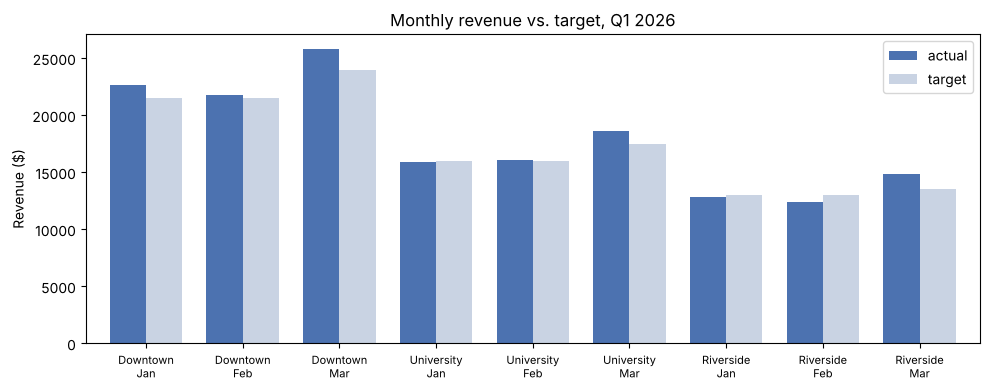

In [35]:
chart = vs_target.set_index(["store", "month"])[["actual", "target"]]
order = [(s, m) for s in ["Downtown", "University", "Riverside"]
         for m in ["Jan", "Feb", "Mar"]]
chart = chart.loc[order]

ax = chart.plot(kind="bar", figsize=(10, 4),
                color=["#4C72B0", "#C9D3E3"], width=0.75)
ax.set_xticklabels([f"{s}\n{m}" for s, m in chart.index], fontsize=8)
ax.set_title("Monthly revenue vs. target, Q1 2026")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../figures/ch08-actual-vs-target.png", dpi=150, bbox_inches="tight")
plt.show()

## 8.9 Summary

## 8.10 Exercises

Open `ch08_transforming.ipynb` and add your answers at the bottom. Solutions are in Appendix D.

1. Using named aggregation, build a table with one row per **product** showing total units, total revenue, and the number of **store-days** on which it sold more than 40 units. *Hint:* for the last one, first add a column `busy` that is `quantity > 40`, then sum it (`True` counts as 1).
2. Use `transform` to add a column with each row's quantity **minus** the average quantity for that store and product. Which single row was furthest above its average?
3. Build a pivot table of **average daily quantity** with products down the side and stores across the top. Round to one decimal place.
4. `melt` the pivot table from Exercise 3 back into a long table with columns `product`, `store` and `avg_qty`. *Hint:* call `.reset_index()` first so `product` is a normal column.
5. Merge `sales` with `stores` and compute revenue **per seat** for each store. Does the ranking differ from revenue per square foot?
6. Use `indicator=True` to list every store in `stores` that has **no** sales rows. *Hint:* use `how="outer"` and keep rows where `_merge` is `"right_only"`.
7. Write one method chain that answers: what was the **gross profit of the Bakery category** at each store, in each month? Use `query` to keep only Bakery rows.
8. **Think about it:** the products table lists a `supplier` for each product. Ridge Roasters says it will raise prices by 10% in April. Estimate how much that would have cut Bean There's Q1 gross profit, assuming the same sales.